# Project 29 — Game-State Reconstruction (Colab)

Reconstructs the state of the card game **29** from overhead-ish gameplay video:
per trick, map *player → card*, track trump and marriage, then score the hand.

**Pipeline**

1. **Table registration** — the footage is hand-held and drifts, so every frame is
   fitted to the table's ellipse and warped onto a canonical top-down disc.
   Everything downstream lives in that stable frame of reference.
2. **Region semantics** — a card's *role* is positional. Table centre = a played
   trick card; the trump spot = the trump indicator (only its **suit** matters, the
   rank is deliberately off-deck); the counter spot = one of the four 6s used for
   scorekeeping; the top edge = face-down hands.
3. **Detection + classification** — YOLO26 over the 32-card closed set, trained on
   scenes composited in canonical space over real table backgrounds.
4. **Seat assignment** — the four played cards land in a cross. Seats come from each
   card's *bearing from that trick's centroid*, so it survives table wander.
5. **Rules engine** — trick winners, marriage, and bid resolution.

> **Read this before trusting the numbers.** No real card scans exist yet, so the
> deck is rendered procedurally. Detection (*where* cards are) will transfer to real
> footage; classification (*which* card) largely will not, because the synthetic faces
> don't look like the real deck. Scan the 32 cards into `data/reference/<CODE>.png`
> to close that gap. Section 9 measures the difference rather than assuming it.

## How to run

1. Put `29-gameplay-1.mp4` and `29-gameplay-2.mp4` anywhere in **your own** Google Drive.
2. In Colab: **Runtime → Change runtime type → GPU** (a free T4 is enough).
3. **Runtime → Run all.** Approve the Drive mount prompt when it appears.

The videos are located by filename, so there is no path to configure. Note that this
must be your own Drive: a folder someone shared with you is not mounted unless you add
a shortcut to it from *Shared with me* (right-click → *Organise* → *Add shortcut*).

Everything else is automatic — no files to upload besides this notebook, no repo to
clone. Expect roughly 25-40 minutes end to end on a T4, most of it training.

The answer you want lands in **section 9**: a table and an array of
`[game][trick] → [P1, P2, P3, P4]`, also written to `reconstruction.json` and
`reconstruction.csv`.

**Optional but strongly recommended:** put scans of the 32 cards in a `reference/`
subfolder of `DRIVE_VIDEO_DIR`, named `JS.png`, `10H.png`, `7C.png`, … Without them
the deck is rendered procedurally and card *identities* will be unreliable — see
section 11.

## 0. Configuration — the only cell you need to edit

## 1. Runtime check

In [2]:
!pip install torch
!pip install -q "ultralytics==8.4.107" 2>&1 | tail -2

Defaulting to user installation because normal site-packages is not writeable


In [19]:
!pip install p29

Defaulting to user installation because normal site-packages is not writeable
  Using cached p29-1.3.0.zip (838 bytes)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for p29: filename=p29-1.3.0-py3-none-any.whl size=1256 sha256=747349d331d8a8da771f4b5cabfb5065a17b4772a3375a997da541a23edde219
  Stored in directory: c:\users\nnahe\appdata\local\pip\cache\wheels\f1\00\e7\882ef869ea18e614e8311441b656dadf31e7a4c672ddea654c
Successfully built p29


In [15]:
%pip install --upgrade --force-reinstall "numpy<2" matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.64.0-cp312-cp312-win_amd64.whl.metadata (126 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached packaging-26.3-py3-none-any.whl.metadata (3.5 kB)
  Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl (9.3 MB)
Using

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
streamlit 1.37.1 requires packaging<25,>=20, but you have packaging 26.3 which is incompatible.
streamlit 1.37.1 requires pillow<11,>=7.1.0, but you have pillow 12.3.0 which is incompatible.


In [22]:
%pip install --force-reinstall --no-cache-dir "numpy==1.26.4" "pandas<3" scipy matplotlib opencv-python

Defaulting to user installation because normal site-packages is not writeable
INFO: pip is looking at multiple versions of scipy to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ------------------- -------------------- 7.6/15.5 MB 39.0 MB/s eta 0:00:01
   ---------------------------------------- 15.5/15.5 MB 39.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   --------------------------- ------------ 7.6/11.0 MB 36.2 MB/s eta 0:00:01
   ---------------------------------------- 11.0/11.0 MB 36.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ------- -------------------------------- 6.8/36.5 MB 34.9 MB/s eta 0:00:01
   -------------- ----------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.17.1 which is incompatible.
streamlit 1.37.1 requires packaging<25,>=20, but you have packaging 26.3 which is incompatible.
streamlit 1.37.1 requires pillow<11,>=7.1.0, but you have pillow 12.3.0 which is incompatible.


In [1]:
import torch, ultralytics
print("torch", torch.__version__, "| cuda", torch.cuda.is_available())
print("ultralytics", ultralytics.__version__)
assert torch.cuda.is_available(), "no GPU - Runtime > Change runtime type > GPU"

torch 2.7.1+cu118 | cuda True
ultralytics 8.4.139


## 2. Project tree

In [2]:
# --- data -------------------------------------------------------------------
# Leave DRIVE_VIDEO_DIR empty to search your Drive for the videos by name -- a
# share link gives a folder id, not a path, so the path cannot be derived from it.
# Set it explicitly only if the search picks the wrong copy.
DRIVE_VIDEO_DIR = ""
VIDEO_GLOB = "29-gameplay-*.mp4"
USE_DRIVE = True          # False -> browser upload widget instead

# --- training ---------------------------------------------------------------
N_TRAIN, N_VAL = 4000, 600   # synthetic scenes
EPOCHS = 60
BATCH = 32                   # drop to 16 if the T4 runs out of memory
IMGSZ = 512                  # must stay equal to CANON_SIZE

# --- reconstruction ---------------------------------------------------------
SAMPLE_FPS = 4.0          # how often to look at the video
CONF = 0.30               # detector threshold; voting tolerates a permissive value

# --- rules ------------------------------------------------------------------
# Who led the very first trick. The video cannot tell you this; in 29 it is the
# bid winner. Every later leader is derived (winner of a trick leads the next).
FIRST_LEADER = 1
DEFAULT_TRUMP_CODE = "S"  # S/H/D/C. Trump is not read off the table yet.
BID_TEAM, BID = "A", 16   # team A = players 1 & 3, team B = 2 & 4

In [3]:
import os
for d in ["p29", "p29/engine", "p29/vision", "p29/datagen",
          "data/raw", "data/reference", "dataset"]:
    os.makedirs(d, exist_ok=True)
for pkg in ["p29", "p29/engine", "p29/vision", "p29/datagen"]:
    open(os.path.join(pkg, "__init__.py"), "w").close()
print("tree ready")

tree ready


## 3. Generate files first 

card_faces, cards, regions, registration, rules, scoring, synthetic_cannon, tracking - these .py files need to be generated first for running the other cells. If they are present already, nothing needs to be done

Copied verbatim from the repo (unit-tested there); regenerate with `tools/build_colab_notebook.py`.

In [8]:
%%writefile cards.py
"""Core card model for the game *29*.

The deck is a fixed closed set of 32 cards: 8 ranks x 4 suits.

Two orderings matter and they are DIFFERENT:
  * point value   -- how many points the card is worth when captured
  * trick strength -- which card beats which within a suit

Standard 29:
    points:   J=3, 9=2, A=1, 10=1, K=0, Q=0, 8=0, 7=0   (28 total)
    strength (high->low): J, 9, A, 10, K, Q, 8, 7
"""

from __future__ import annotations

from dataclasses import dataclass
from enum import Enum


class Suit(Enum):
    SPADES = "S"
    HEARTS = "H"
    DIAMONDS = "D"
    CLUBS = "C"

    @property
    def symbol(self) -> str:
        return {"S": "♠", "H": "♥", "D": "♦", "C": "♣"}[self.value]


class Rank(Enum):
    SEVEN = "7"
    EIGHT = "8"
    NINE = "9"
    TEN = "10"
    JACK = "J"
    QUEEN = "Q"
    KING = "K"
    ACE = "A"


# Point value captured when a card is won in a trick. Sums to 28 across the deck.
RANK_POINTS: dict[Rank, int] = {
    Rank.JACK: 3,
    Rank.NINE: 2,
    Rank.ACE: 1,
    Rank.TEN: 1,
    Rank.KING: 0,
    Rank.QUEEN: 0,
    Rank.EIGHT: 0,
    Rank.SEVEN: 0,
}

# Trick-taking strength, high -> low. Larger int beats smaller (within a suit).
_RANK_STRENGTH_ORDER: list[Rank] = [
    Rank.JACK,
    Rank.NINE,
    Rank.ACE,
    Rank.TEN,
    Rank.KING,
    Rank.QUEEN,
    Rank.EIGHT,
    Rank.SEVEN,
]
# Assign so that JACK is highest.
RANK_STRENGTH: dict[Rank, int] = {
    rank: len(_RANK_STRENGTH_ORDER) - 1 - i
    for i, rank in enumerate(_RANK_STRENGTH_ORDER)
}


@dataclass(frozen=True)
class Card:
    """An immutable, hashable card. Suitable as a dict key / set member."""

    rank: Rank
    suit: Suit

    @property
    def points(self) -> int:
        return RANK_POINTS[self.rank]

    @property
    def strength(self) -> int:
        """Rank strength for trick comparison (suit-agnostic; compare within a suit)."""
        return RANK_STRENGTH[self.rank]

    @property
    def code(self) -> str:
        """Compact code like ``'JS'`` (Jack of Spades) or ``'10H'``."""
        return f"{self.rank.value}{self.suit.value}"

    def __str__(self) -> str:  # pragma: no cover - display only
        return f"{self.rank.value}{self.suit.symbol}"

    @classmethod
    def from_code(cls, code: str) -> "Card":
        """Parse ``'JS'`` / ``'10H'`` / ``'7c'`` back into a Card (case-insensitive)."""
        code = code.strip().upper()
        suit_char = code[-1]
        rank_str = code[:-1]
        try:
            suit = Suit(suit_char)
        except ValueError as exc:
            raise ValueError(f"Unknown suit in card code {code!r}") from exc
        try:
            rank = Rank(rank_str)
        except ValueError as exc:
            raise ValueError(f"Unknown rank in card code {code!r}") from exc
        return cls(rank, suit)


def full_deck() -> list[Card]:
    """Return all 32 distinct cards of the fixed *29* deck."""
    return [Card(rank, suit) for suit in Suit for rank in Rank]


# Convenience: total points in the deck (invariant == 28).
DECK_TOTAL_POINTS = sum(c.points for c in full_deck())

Overwriting cards.py


In [9]:
%%writefile rules.py
"""Trick-taking rules for *29*: play model, trick-winner, and marriage detection.

These functions are the deterministic heart of the system. They take *already
identified* cards (rank+suit + which player played them) and produce trick
winners, captured points, and marriage events. They contain no CV logic, so they
can be unit-tested exhaustively against hand-computed games.

Player / team model
-------------------
Players are labelled 1..4 by seat. Players sitting opposite are partners:
    Team A = {1, 3}
    Team B = {2, 4}
"""

from __future__ import annotations

from dataclasses import dataclass

from .cards import Card, Rank, Suit

PLAYERS = (1, 2, 3, 4)
TEAM_A = frozenset({1, 3})
TEAM_B = frozenset({2, 4})

# Seating order around the table. Partners sit opposite, so going round the table
# alternates teams: 1 (A), 2 (B), 3 (A), 4 (B).
SEATING_ORDER = (1, 2, 3, 4)


def order_from_leader(leader: int) -> list[int]:
    """Return the play order for a trick led by ``leader``, going round the table.

    Play order is not observed from the video -- it is derived. The winner of a
    trick leads the next one, so once the first leader is known every subsequent
    order follows from the trick outcomes.
    """
    if leader not in SEATING_ORDER:
        raise ValueError(f"leader must be one of {SEATING_ORDER}, got {leader!r}")
    start = SEATING_ORDER.index(leader)
    return [SEATING_ORDER[(start + step) % len(SEATING_ORDER)] for step in range(4)]


def team_of(player: int) -> frozenset[int]:
    """Return the partner-set (team) that ``player`` belongs to."""
    if player in TEAM_A:
        return TEAM_A
    if player in TEAM_B:
        return TEAM_B
    raise ValueError(f"player must be one of {PLAYERS}, got {player!r}")


@dataclass(frozen=True)
class Play:
    """A single card played by a player. ``order`` is 0..3 within the trick."""

    player: int
    card: Card
    order: int


@dataclass(frozen=True)
class Trick:
    """The four plays of one trick, in play order (index 0 == leader)."""

    plays: tuple[Play, ...]

    def __post_init__(self) -> None:
        if len(self.plays) != 4:
            raise ValueError(f"a trick has exactly 4 plays, got {len(self.plays)}")
        players = {p.player for p in self.plays}
        if players != set(PLAYERS):
            raise ValueError(f"a trick must have all of players {PLAYERS}, got {players}")
        cards = [p.card for p in self.plays]
        if len(set(cards)) != 4:
            raise ValueError(f"duplicate card within a trick: {cards}")

    @property
    def leader(self) -> int:
        return self.ordered()[0].player

    @property
    def led_suit(self) -> Suit:
        return self.ordered()[0].card.suit

    def ordered(self) -> list[Play]:
        """Plays sorted by play order (leader first)."""
        return sorted(self.plays, key=lambda p: p.order)

    @property
    def points(self) -> int:
        """Total captured points available in this trick."""
        return sum(p.card.points for p in self.plays)

    @classmethod
    def from_mapping(
        cls, player_to_card: dict[int, Card], order: list[int] | None = None
    ) -> "Trick":
        """Build a Trick from ``{player: card}`` plus an optional play order.

        ``order`` is the list of players in the sequence they played
        (e.g. ``[2, 3, 4, 1]``). Defaults to ``[1, 2, 3, 4]``.
        """
        order = order or list(PLAYERS)
        if sorted(order) != list(PLAYERS):
            raise ValueError(f"order must be a permutation of {PLAYERS}, got {order}")
        plays = tuple(
            Play(player=pl, card=player_to_card[pl], order=i)
            for i, pl in enumerate(order)
        )
        return cls(plays)


def trick_winner(trick: Trick, trump_suit: Suit | None) -> int:
    """Return the player who wins ``trick``.

    Rules:
      * If any trump was played, the highest-strength trump wins.
      * Otherwise the highest-strength card of the *led* suit wins.
      * ``trump_suit=None`` means trump is not (yet) active -> led-suit only.

    Note on reveal timing: trump only becomes active once revealed. Callers that
    model a mid-game reveal should pass ``trump_suit=None`` for tricks played
    before trump is active and the actual suit from the reveal trick onward.
    """
    ordered = trick.ordered()
    if trump_suit is not None:
        trumps = [p for p in ordered if p.card.suit == trump_suit]
        if trumps:
            return max(trumps, key=lambda p: p.card.strength).player

    led = trick.led_suit
    followers = [p for p in ordered if p.card.suit == led]
    # followers is always non-empty (the leader itself follows the led suit).
    return max(followers, key=lambda p: p.card.strength).player


def detect_marriage(
    tricks: list[Trick],
    trump_suit: Suit | None,
    reveal_trick_index: int | None,
) -> int | None:
    """Return the player who scored a marriage, or ``None``.

    Marriage (per project spec): the King AND Queen of the *trump* suit are both
    played by the *same* player, *after* the trump reveal.

    ``reveal_trick_index`` is the index into ``tricks`` at which trump becomes
    active (inclusive). Plays in earlier tricks do not count toward marriage.
    ``None`` for either trump argument means no marriage is possible.
    """
    if trump_suit is None or reveal_trick_index is None:
        return None

    king = Card(Rank.KING, trump_suit)
    queen = Card(Rank.QUEEN, trump_suit)
    king_by: int | None = None
    queen_by: int | None = None

    for idx, trick in enumerate(tricks):
        if idx < reveal_trick_index:
            continue
        for play in trick.plays:
            if play.card == king:
                king_by = play.player
            elif play.card == queen:
                queen_by = play.player

    if king_by is not None and king_by == queen_by:
        return king_by
    return None

Writing rules.py


In [10]:
%%writefile scoring.py
"""Hand-level scoring for *29*: tally team points and resolve the bid.

Consumes the deterministic outputs of :mod:`rules` (trick winners, captured
points, marriage) and produces the final result of a hand: each team's score and
whether the bidding team made its contract.
"""

from __future__ import annotations

from dataclasses import dataclass, field

from .cards import Card, Suit
from .rules import (
    TEAM_A,
    TEAM_B,
    Trick,
    detect_marriage,
    order_from_leader,
    team_of,
    trick_winner,
)

# Marriage bonus points. Configurable; 4 is the common value in *29*.
DEFAULT_MARRIAGE_BONUS = 4


def _team_name(team: frozenset[int]) -> str:
    return "A" if team == TEAM_A else "B"


@dataclass
class TrumpInfo:
    """Describes the trump for a hand.

    * ``suit``               -- the trump suit, or None if never revealed on camera.
    * ``reveal_trick_index`` -- index into the hand's trick list at which trump
      becomes active (inclusive). None if trump was never revealed.
    """

    suit: Suit | None = None
    reveal_trick_index: int | None = None

    @property
    def is_active(self) -> bool:
        return self.suit is not None and self.reveal_trick_index is not None


@dataclass
class HandResult:
    team_points: dict[str, int]
    trick_winners: list[int]
    marriage_player: int | None
    marriage_team: str | None
    # Leader of each trick, in order. Derived from the previous trick's winner,
    # never observed from the video.
    trick_leaders: list[int] = field(default_factory=list)
    bidding_team: str | None = None
    bid: int | None = None
    contract_made: bool | None = None
    winning_team: str | None = None
    detail: list[dict] = field(default_factory=list)


def score_hand(
    tricks: list[Trick],
    trump: TrumpInfo,
    *,
    bidding_team: str | None = None,
    bid: int | None = None,
    marriage_bonus: int = DEFAULT_MARRIAGE_BONUS,
) -> HandResult:
    """Score one hand (one deal of 8 tricks) and resolve the bid if given.

    ``bidding_team`` is ``"A"`` or ``"B"`` (from user text input); ``bid`` is the
    contracted point target. If both are supplied, the bidding team must capture
    >= ``bid`` points (including any marriage bonus it earned) to make contract;
    otherwise the opposing team wins the hand.
    """
    points = {"A": 0, "B": 0}
    winners: list[int] = []
    detail: list[dict] = []

    for idx, trick in enumerate(tricks):
        # Trump is only active from the reveal trick onward.
        active_suit = (
            trump.suit
            if trump.is_active and idx >= trump.reveal_trick_index  # type: ignore[operator]
            else None
        )
        winner = trick_winner(trick, active_suit)
        winners.append(winner)
        team = _team_name(team_of(winner))
        points[team] += trick.points
        detail.append(
            {
                "trick": idx,
                "winner": winner,
                "team": team,
                "points": trick.points,
                "trump_active": active_suit.value if active_suit else None,
            }
        )

    # Marriage bonus.
    marriage_player = detect_marriage(tricks, trump.suit, trump.reveal_trick_index)
    marriage_team: str | None = None
    if marriage_player is not None:
        marriage_team = _team_name(team_of(marriage_player))
        points[marriage_team] += marriage_bonus

    result = HandResult(
        team_points=points,
        trick_winners=winners,
        marriage_player=marriage_player,
        marriage_team=marriage_team,
        bidding_team=bidding_team,
        bid=bid,
        detail=detail,
    )

    result.trick_leaders = [t.leader for t in tricks]

    # Resolve the contract.
    if bidding_team is not None and bid is not None:
        if bidding_team not in ("A", "B"):
            raise ValueError(f"bidding_team must be 'A' or 'B', got {bidding_team!r}")
        made = points[bidding_team] >= bid
        result.contract_made = made
        other = "B" if bidding_team == "A" else "A"
        result.winning_team = bidding_team if made else other

    return result


def build_tricks_from_plays(
    plays: list[dict[int, Card]],
    trump: TrumpInfo,
    first_leader: int,
) -> list[Trick]:
    """Turn per-trick ``{player: card}`` mappings into ordered :class:`Trick` objects.

    Vision recovers *who played what*, not the sequence. The sequence is derived:
    the winner of a trick leads the next, going round the table from there. So the
    whole chain follows from ``first_leader``.

    This is not bookkeeping -- the leader fixes the *led suit*, which decides the
    winner whenever no trump is played. Get a leader wrong and the winner can
    change, which changes the next leader, so an early error propagates.
    """
    tricks: list[Trick] = []
    leader = first_leader

    for index, mapping in enumerate(plays):
        trick = Trick.from_mapping(mapping, order=order_from_leader(leader))
        tricks.append(trick)

        active_suit = (
            trump.suit
            if trump.is_active and index >= trump.reveal_trick_index  # type: ignore[operator]
            else None
        )
        leader = trick_winner(trick, active_suit)

    return tricks


def score_hand_from_plays(
    plays: list[dict[int, Card]],
    trump: TrumpInfo,
    *,
    first_leader: int = 1,
    bidding_team: str | None = None,
    bid: int | None = None,
    marriage_bonus: int = DEFAULT_MARRIAGE_BONUS,
) -> HandResult:
    """Score a hand straight from ``{player: card}`` mappings, deriving play order.

    ``first_leader`` is the only ordering input the video cannot supply; in *29* it
    is the bid winner. Every later leader is computed from the trick outcomes.
    """
    tricks = build_tricks_from_plays(plays, trump, first_leader)
    return score_hand(
        tricks,
        trump,
        bidding_team=bidding_team,
        bid=bid,
        marriage_bonus=marriage_bonus,
    )

Writing scoring.py


In [28]:
%%writefile registration.py
"""Table registration: map a drifting hand-held view onto a canonical top-down table.

The gameplay footage is shot hand-held at an oblique angle, so the table wanders
around the frame between (and within) tricks. Every downstream notion of "where a
card is" -- which arm of the trick cross, the trump spot, the counter spot -- is
only meaningful in a frame of reference attached to the *table*, not to the image.

The round table projects to an ellipse. We fit that ellipse on the cane (rattan)
surface, then apply the affine map that turns the ellipse back into a circle of
radius ``CANON_RADIUS`` centred in a ``CANON_SIZE`` square. That removes the
translation, scale and foreshortening drift, which is what actually moves between
frames. It deliberately stops short of a full perspective rectification: recovering
a true homography from a single conic is ambiguous without a second cue, and the
affine approximation is both stable and sufficient for region assignment.

In-plane orientation is preserved (the ellipse's tilt is re-applied after the
circularising scale) so that "players sit along the top edge" stays true in
canonical space.
"""

from __future__ import annotations

from dataclasses import dataclass

import cv2
import numpy as np

# Canonical table space: a CANON_SIZE x CANON_SIZE image with the table drawn as a
# centred circle of radius CANON_RADIUS.
CANON_SIZE = 512
CANON_RADIUS = 230.0

# Cane-surface colour gate in HSV. The table top is a warm tan/orange weave; the
# floor tiles around it are desaturated pink-grey and the rim is near-black.
_CANE_LOWER = np.array([5, 60, 80], dtype=np.uint8)
_CANE_UPPER = np.array([35, 255, 255], dtype=np.uint8)

# Plausibility gates on a candidate ellipse, as fractions of frame area / extent.
_MIN_AREA_FRAC = 0.04
_MAX_AREA_FRAC = 0.90
_MAX_AXIS_RATIO = 4.0


@dataclass(frozen=True)
class TableFit:
    """A fitted table ellipse plus the affine map into canonical table space."""

    cx: float
    cy: float
    major: float  # full length of the major axis, pixels
    minor: float  # full length of the minor axis, pixels
    angle: float  # major-axis tilt in degrees, OpenCV convention
    score: float  # fraction of the ellipse actually covered by cane pixels

    @property
    def center(self) -> tuple[float, float]:
        return self.cx, self.cy

    def to_canonical(self) -> np.ndarray:
        """Return the 2x3 affine mapping image pixels -> canonical table space."""
        a = max(self.major / 2.0, 1e-6)
        b = max(self.minor / 2.0, 1e-6)
        theta = np.deg2rad(self.angle)

        # Rotate the major axis onto x, squash both axes to CANON_RADIUS, then put
        # the original tilt back so the table's in-image orientation is preserved.
        c, s = np.cos(theta), np.sin(theta)
        rot_to_axis = np.array([[c, s], [-s, c]])
        scale = np.diag([CANON_RADIUS / a, CANON_RADIUS / b])
        rot_back = np.array([[c, -s], [s, c]])
        linear = rot_back @ scale @ rot_to_axis

        offset = np.array([CANON_SIZE / 2.0, CANON_SIZE / 2.0]) - linear @ np.array(
            [self.cx, self.cy]
        )
        return np.hstack([linear, offset.reshape(2, 1)])

    def warp(self, frame: np.ndarray) -> np.ndarray:
        """Warp a frame into canonical table space."""
        return cv2.warpAffine(
            frame,
            self.to_canonical(),
            (CANON_SIZE, CANON_SIZE),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_CONSTANT,
        )

    def points_to_canonical(self, pts: np.ndarray) -> np.ndarray:
        """Map an (N,2) array of image points into canonical table space."""
        pts = np.asarray(pts, dtype=np.float64).reshape(-1, 2)
        m = self.to_canonical()
        return pts @ m[:, :2].T + m[:, 2]

    def points_from_canonical(self, pts: np.ndarray) -> np.ndarray:
        """Map an (N,2) array of canonical points back into image pixels."""
        pts = np.asarray(pts, dtype=np.float64).reshape(-1, 2)
        m = self.to_canonical()
        inv = np.linalg.inv(m[:, :2])
        return (pts - m[:, 2]) @ inv.T


def _cane_mask(frame: np.ndarray) -> np.ndarray:
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, _CANE_LOWER, _CANE_UPPER)
    # The weave is full of holes; close hard enough to make the top a solid blob.
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    return mask


def fit_table(frame: np.ndarray) -> TableFit | None:
    """Fit the table ellipse in a single frame, or None if no plausible table."""
    h, w = frame.shape[:2]
    mask = _cane_mask(frame)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    frame_area = float(h * w)
    best: TableFit | None = None
    for contour in contours:
        if len(contour) < 5:
            continue
        # Cards and hands sit *on* the table and punch holes in the cane mask, so
        # use the convex hull -- we want the outline of the top, not of the weave.
        hull = cv2.convexHull(contour)
        if cv2.contourArea(hull) < _MIN_AREA_FRAC * frame_area:
            continue
        if len(hull) < 5:
            continue

        (cx, cy), (axis_a, axis_b), angle = cv2.fitEllipse(hull)
        major, minor = max(axis_a, axis_b), min(axis_a, axis_b)
        if minor <= 1.0 or major / minor > _MAX_AXIS_RATIO:
            continue

        ellipse_area = np.pi * (major / 2.0) * (minor / 2.0)
        if not (_MIN_AREA_FRAC * frame_area <= ellipse_area <= _MAX_AREA_FRAC * frame_area):
            continue

        # How much of the fitted ellipse is really cane? Guards against latching
        # onto a wooden bench or a stretch of warm-toned floor.
        probe = np.zeros((h, w), dtype=np.uint8)
        cv2.ellipse(probe, ((cx, cy), (axis_a, axis_b), angle), 255, -1)
        probe_area = float(np.count_nonzero(probe))
        if probe_area < 1.0:
            continue
        score = float(np.count_nonzero(cv2.bitwise_and(probe, mask))) / probe_area
        if score < 0.45:
            continue

        # fitEllipse reports the angle of axis_a; re-express it for the major axis.
        major_angle = angle if axis_a >= axis_b else angle + 90.0
        candidate = TableFit(cx, cy, major, minor, major_angle % 180.0, score)
        if best is None or ellipse_area > best.major * best.minor * np.pi / 4.0:
            best = candidate

    return best


class TableTracker:
    """Temporally smoothed table fit.

    Per-frame fits jitter and occasionally fail outright (a hand sweeping across
    the top, a bad exposure). This keeps an exponential moving average and holds
    the last good fit through short dropouts, so canonical coordinates stay
    continuous across a trick.
    """

    def __init__(self, alpha: float = 0.2, max_hold: int = 90) -> None:
        self.alpha = alpha
        self.max_hold = max_hold
        self._state: TableFit | None = None
        self._misses = 0

    @property
    def current(self) -> TableFit | None:
        return self._state

    def update(self, frame: np.ndarray) -> TableFit | None:
        fit = fit_table(frame)
        if fit is None:
            self._misses += 1
            if self._misses > self.max_hold:
                self._state = None
            return self._state

        self._misses = 0
        if self._state is None:
            self._state = fit
            return self._state

        a = self.alpha
        prev = self._state
        # Average the tilt on the doubled angle: the major axis is 180-periodic, so
        # naive averaging would tear when the fit crosses 0/180.
        prev_r, cur_r = np.deg2rad(prev.angle * 2), np.deg2rad(fit.angle * 2)
        blended = np.arctan2(
            (1 - a) * np.sin(prev_r) + a * np.sin(cur_r),
            (1 - a) * np.cos(prev_r) + a * np.cos(cur_r),
        )
        self._state = TableFit(
            cx=(1 - a) * prev.cx + a * fit.cx,
            cy=(1 - a) * prev.cy + a * fit.cy,
            major=(1 - a) * prev.major + a * fit.major,
            minor=(1 - a) * prev.minor + a * fit.minor,
            angle=float(np.rad2deg(blended) / 2.0) % 180.0,
            score=(1 - a) * prev.score + a * fit.score,
        )
        return self._state

Writing registration.py


In [29]:
%%writefile regions.py
"""Region semantics in canonical table space.

A card's *role* in this footage is positional, not visual: the same 3 of diamonds
is a trump indicator on the trump spot and would be meaningless in the trick area.
This module turns a canonical-space position into a role, and -- for trick cards --
into a player seat.

Two distinct mechanisms, on purpose:

* **Role** (trick / trump / counter / hand) is decided by *absolute* position in
  canonical space, since those areas are fixed properties of how the table is laid
  out. They are configurable because the trump and counter spots are conventions of
  this particular group, not of the game.

* **Seat** is decided by the *bearing of a card from the centroid of the current
  trick*, not by absolute position. The four played cards land in a cross, and the
  cross as a whole shifts around the table between tricks. Measuring each card
  relative to its own trick's centre is invariant to that wander, and to any
  residual rotation the registration step leaves behind.
"""

from __future__ import annotations

import json
import math
from dataclasses import dataclass, field
from enum import Enum

import numpy as np

from .registration import CANON_RADIUS, CANON_SIZE

CANON_CENTER = (CANON_SIZE / 2.0, CANON_SIZE / 2.0)


class Role(str, Enum):
    """What a detected card means, given where it sits."""

    TRICK = "trick"  # a played card in the current trick
    TRUMP = "trump"  # the trump indicator (suit matters, rank is noise)
    COUNTER = "counter"  # one of the four 6s used as a point counter
    HAND = "hand"  # a player's face-down pile along the table edge
    UNKNOWN = "unknown"


@dataclass(frozen=True)
class Disc:
    """A circular region in canonical space, as fractions of the table radius."""

    cx: float
    cy: float
    radius: float

    def contains(self, x: float, y: float) -> bool:
        return math.hypot(x - self.cx, y - self.cy) <= self.radius


@dataclass
class TableLayout:
    """Where each role lives in canonical table space.

    Defaults are derived from the canonical persistence maps of both gameplay
    videos: three hand piles hug the top edge, and the trick cross sits in the
    lower-middle of the table. The trump and counter spots are deliberately wide
    and overridable -- they were inferred from a handful of frames, so they are
    config, not fact.
    """

    # Cards beyond this fraction of the table radius, in the upper half, are piles.
    hand_band_radius: float = 0.62
    hand_band_max_angle: float = 115.0  # degrees from "up", either side

    trick_area: Disc = field(
        default_factory=lambda: Disc(
            cx=CANON_CENTER[0] - 0.04 * CANON_RADIUS,
            cy=CANON_CENTER[1] + 0.22 * CANON_RADIUS,
            radius=0.72 * CANON_RADIUS,
        )
    )
    trump_spot: Disc | None = None
    counter_spot: Disc | None = None

    def to_json(self, path: str) -> None:
        def enc(d: Disc | None):
            return None if d is None else {"cx": d.cx, "cy": d.cy, "radius": d.radius}

        payload = {
            "hand_band_radius": self.hand_band_radius,
            "hand_band_max_angle": self.hand_band_max_angle,
            "trick_area": enc(self.trick_area),
            "trump_spot": enc(self.trump_spot),
            "counter_spot": enc(self.counter_spot),
        }
        with open(path, "w") as fh:
            json.dump(payload, fh, indent=2)

    @classmethod
    def from_json(cls, path: str) -> "TableLayout":
        with open(path) as fh:
            payload = json.load(fh)

        def dec(d):
            return None if d is None else Disc(d["cx"], d["cy"], d["radius"])

        return cls(
            hand_band_radius=payload["hand_band_radius"],
            hand_band_max_angle=payload["hand_band_max_angle"],
            trick_area=dec(payload["trick_area"]),
            trump_spot=dec(payload["trump_spot"]),
            counter_spot=dec(payload["counter_spot"]),
        )

    def classify(self, x: float, y: float) -> Role:
        """Assign a role to a canonical-space point (centre of a detected card)."""
        # Explicitly configured spots win: they are narrow and deliberate, whereas
        # the hand band and trick area are broad catch-alls that would swallow them.
        if self.trump_spot is not None and self.trump_spot.contains(x, y):
            return Role.TRUMP
        if self.counter_spot is not None and self.counter_spot.contains(x, y):
            return Role.COUNTER

        dx, dy = x - CANON_CENTER[0], y - CANON_CENTER[1]
        radius_frac = math.hypot(dx, dy) / CANON_RADIUS
        # Bearing measured from "up" (negative y), positive clockwise.
        bearing = math.degrees(math.atan2(dx, -dy))
        if radius_frac >= self.hand_band_radius and abs(bearing) <= self.hand_band_max_angle:
            return Role.HAND

        if self.trick_area.contains(x, y):
            return Role.TRICK
        if radius_frac > 1.05:
            return Role.UNKNOWN
        return Role.TRICK


# Seat order around the cross, clockwise starting from the arm nearest the camera.
# The fourth player sits off-frame on the camera side, so their card lands in the
# south arm; the three visible players fill west, north and east.
_SEAT_BEARINGS = {
    "south": 180.0,
    "west": 270.0,
    "north": 0.0,
    "east": 90.0,
}


def assign_seats(points: np.ndarray) -> list[str]:
    """Map trick-card positions to cross arms by bearing from the trick centroid.

    ``points`` is an (N,2) array of canonical-space card centres belonging to one
    trick (N <= 4). Returns the arm name per point. Each arm is used at most once:
    with fewer than four cards the centroid is pulled off-centre, so a greedy
    nearest-bearing assignment would happily put two cards on the same arm.
    """
    pts = np.asarray(points, dtype=np.float64).reshape(-1, 2)
    if len(pts) == 0:
        return []

    centroid = pts.mean(axis=0)
    bearings = np.degrees(np.arctan2(pts[:, 0] - centroid[0], -(pts[:, 1] - centroid[1])))

    names = list(_SEAT_BEARINGS)
    # Cost = angular distance from each card to each arm, then a small exhaustive
    # search for the lowest-cost one-to-one assignment (at most 4! = 24 options).
    cost = np.zeros((len(pts), len(names)))
    for i, b in enumerate(bearings):
        for j, name in enumerate(names):
            diff = abs((b - _SEAT_BEARINGS[name] + 180.0) % 360.0 - 180.0)
            cost[i, j] = diff

    from itertools import permutations

    best_total, best_choice = float("inf"), None
    for choice in permutations(range(len(names)), len(pts)):
        total = sum(cost[i, j] for i, j in enumerate(choice))
        if total < best_total:
            best_total, best_choice = total, choice

    assert best_choice is not None
    return [names[j] for j in best_choice]

Writing regions.py


In [30]:
%%writefile tracking.py
"""Temporal layer: frames -> tricks -> games -> {player: card} per trick.

Single-frame detection is not the deliverable. What matters is, per game and per
trick, which card each player played. Getting there needs three things that only
exist across time:

1. **Trick segmentation.** Cards accumulate in the play area, then get swept up
   when the trick is taken. That sweep is the boundary. A trick is the span
   between two sweeps.

2. **Voting within a trick.** A card sits on the table for many frames, so it gets
   classified many times. The consensus over those frames is far stronger than any
   single frame -- which is the point, given a played card is only ~55x85 px.

3. **The uniqueness constraint.** Each of the 32 cards is played exactly once per
   game. That turns identification into a global assignment problem rather than 32
   independent guesses, and it repairs errors that no amount of per-frame
   confidence would: if the model likes 9H for two different slots, at most one can
   keep it, and the other is forced to its best remaining option.

Seating is only read off frames where the trick is at its fullest. With one or two
cards down, the centroid sits on top of the cards themselves and the bearing that
:func:`assign_seats` relies on is meaningless.
"""

from __future__ import annotations

from collections import defaultdict
from dataclasses import dataclass, field

import numpy as np

from .regions import assign_seats

# Seats, in the fixed cross arrangement, mapped to the engine's player numbers.
# Player 4 sits off-frame nearest the camera and plays into the south arm.
SEAT_TO_PLAYER: dict[str, int] = {"south": 4, "west": 1, "north": 2, "east": 3}


@dataclass(frozen=True)
class Detection:
    """One detected trick card in canonical table space."""

    code: str
    conf: float
    x: float
    y: float


@dataclass
class RawTrick:
    """A segmented trick, before uniqueness is enforced across the game."""

    start_frame: int
    end_frame: int
    peak_cards: int
    # seat -> {card code -> accumulated confidence}
    votes: dict[str, dict[str, float]] = field(default_factory=dict)

    def best_by_seat(self) -> dict[str, str]:
        """Greedy per-seat winner, ignoring the uniqueness constraint."""
        out = {}
        for seat, tally in self.votes.items():
            if tally:
                out[seat] = max(tally, key=tally.get)
        return out


class TrickSegmenter:
    """Turn a stream of per-frame detections into discrete tricks.

    ``min_empty_frames`` is how many consecutive card-free observations count as a
    sweep; it debounces the frequent single-frame dropout (a hand crossing the
    table, a bad exposure) that would otherwise split one trick into several.
    """

    def __init__(
        self,
        min_empty_frames: int = 3,
        min_peak_cards: int = 2,
        max_cards: int = 4,
        min_trick_frames: int = 0,
    ) -> None:
        self.min_empty_frames = min_empty_frames
        self.min_peak_cards = min_peak_cards
        self.max_cards = max_cards
        self.min_trick_frames = min_trick_frames
        # Segments dropped for being too short/weak, for diagnostics.
        self.rejected = 0
        self._observations: list[tuple[int, list[Detection]]] = []
        self._empty_streak = 0
        self._start_frame: int | None = None
        self.tricks: list[RawTrick] = []

    def feed(self, frame_index: int, detections: list[Detection]) -> None:
        detections = sorted(detections, key=lambda d: -d.conf)[: self.max_cards]

        if detections:
            self._empty_streak = 0
            if self._start_frame is None:
                self._start_frame = frame_index
            self._observations.append((frame_index, detections))
            return

        self._empty_streak += 1
        if self._observations and self._empty_streak >= self.min_empty_frames:
            self._close(frame_index)

    def finish(self) -> list[RawTrick]:
        """Close any trick still open at end of stream and return all tricks."""
        if self._observations:
            self._close(self._observations[-1][0])
        return self.tricks

    def _close(self, end_frame: int) -> None:
        observations = self._observations
        self._observations = []
        self._empty_streak = 0
        start = self._start_frame
        self._start_frame = None

        peak = max(len(d) for _, d in observations)
        if peak < self.min_peak_cards or start is None:
            self.rejected += 1
            return  # stray detections, not a real trick

        # A real trick lasts as long as it takes four players to play. Anything
        # briefer is detector flicker: on the real footage a naive emptiness test
        # fires an order of magnitude more often than there are actual tricks.
        if observations[-1][0] - start < self.min_trick_frames:
            self.rejected += 1
            return

        # Seat only from the fullest frames -- see the module docstring.
        fullest = [(idx, dets) for idx, dets in observations if len(dets) == peak]
        votes: dict[str, dict[str, float]] = defaultdict(lambda: defaultdict(float))
        for _, dets in fullest:
            seats = assign_seats(np.array([[d.x, d.y] for d in dets]))
            for det, seat in zip(dets, seats):
                votes[seat][det.code] += det.conf

        self.tricks.append(
            RawTrick(
                start_frame=start,
                end_frame=end_frame,
                peak_cards=peak,
                votes={s: dict(t) for s, t in votes.items()},
            )
        )


def split_games(
    tricks: list[RawTrick],
    tricks_per_game: int = 8,
    deal_gap_frames: int | None = None,
) -> list[list[RawTrick]]:
    """Group tricks into games.

    A game is ``tricks_per_game`` tricks. When ``deal_gap_frames`` is given, an
    unusually long card-free stretch (the deal) also closes a game, which recovers
    the grouping when a trick is missed or spuriously split.
    """
    games: list[list[RawTrick]] = []
    current: list[RawTrick] = []

    for i, trick in enumerate(tricks):
        if current and deal_gap_frames is not None:
            gap = trick.start_frame - current[-1].end_frame
            if gap >= deal_gap_frames:
                games.append(current)
                current = []
        current.append(trick)
        if len(current) == tricks_per_game:
            games.append(current)
            current = []

    if current:
        games.append(current)
    return games


def enforce_uniqueness(
    game_tricks: list[RawTrick], all_codes: list[str]
) -> list[dict[str, str]]:
    """Resolve a whole game at once, so each card is used at most once.

    Returns one ``{seat: card_code}`` mapping per trick. Solves a maximum-weight
    assignment over every (trick, seat) slot against the 32 cards, using the voted
    confidences as weights -- rather than taking each slot's argmax independently
    and hoping no card gets claimed twice.
    """
    slots: list[tuple[int, str]] = []
    for t_idx, trick in enumerate(game_tricks):
        for seat in trick.votes:
            slots.append((t_idx, seat))

    if not slots:
        return [{} for _ in game_tricks]

    code_index = {c: i for i, c in enumerate(all_codes)}
    score = np.zeros((len(slots), len(all_codes)))
    for row, (t_idx, seat) in enumerate(slots):
        for codeval, weight in game_tricks[t_idx].votes[seat].items():
            if codeval in code_index:
                score[row, code_index[codeval]] = weight

    try:
        from scipy.optimize import linear_sum_assignment

        rows, cols = linear_sum_assignment(score, maximize=True)
        pairs = list(zip(rows, cols))
    except ImportError:  # pragma: no cover - scipy ships with Colab
        pairs = _greedy_assignment(score)

    result: list[dict[str, str]] = [{} for _ in game_tricks]
    for row, col in pairs:
        # A slot with no vote mass at all would otherwise be handed an arbitrary
        # leftover card purely to complete the matching.
        if score[row, col] <= 0:
            continue
        t_idx, seat = slots[row]
        result[t_idx][seat] = all_codes[col]
    return result


def _greedy_assignment(score: np.ndarray) -> list[tuple[int, int]]:
    """Fallback for the assignment problem: repeatedly take the best free pair."""
    pairs = []
    used_rows: set[int] = set()
    used_cols: set[int] = set()
    order = np.dstack(np.unravel_index(np.argsort(score, axis=None)[::-1], score.shape))[0]
    for row, col in order:
        if row in used_rows or col in used_cols:
            continue
        used_rows.add(int(row))
        used_cols.add(int(col))
        pairs.append((int(row), int(col)))
    return pairs


def to_player_mapping(seat_mapping: dict[str, str]) -> dict[int, str]:
    """Convert ``{seat: code}`` to ``{player_number: code}``."""
    return {SEAT_TO_PLAYER[seat]: codeval for seat, codeval in seat_mapping.items()}

Writing tracking.py


### Procedural deck and the canonical-space scene compositor

In [23]:
%%writefile card_faces.py
"""Procedurally rendered card faces for the 32-card *29* deck.

These exist so the pipeline is trainable *before* real card scans are available.
Faces are drawn geometrically rather than with a font, so nothing depends on
which glyphs the runtime happens to ship.

They are a stand-in, not a substitute: a classifier trained purely on these will
learn this synthetic look. Drop real scans into ``data/reference/<CODE>.png``
(e.g. ``JS.png``, ``10H.png``) and ``load_gallery`` prefers them automatically.
"""

from __future__ import annotations

import os

import numpy as np
from PIL import Image, ImageDraw

CARD_W, CARD_H = 140, 200
RED = (200, 30, 40)
BLACK = (25, 25, 30)

RANKS = ["7", "8", "9", "10", "J", "Q", "K", "A"]
SUITS = ["S", "H", "D", "C"]
SUIT_COLOR = {"S": BLACK, "C": BLACK, "H": RED, "D": RED}


def _diamond(draw, cx, cy, r, color):
    draw.polygon([(cx, cy - r), (cx + r * 0.72, cy), (cx, cy + r), (cx - r * 0.72, cy)], fill=color)


def _heart(draw, cx, cy, r, color):
    draw.ellipse([cx - r, cy - r * 0.95, cx, cy + r * 0.1], fill=color)
    draw.ellipse([cx, cy - r * 0.95, cx + r, cy + r * 0.1], fill=color)
    draw.polygon([(cx - r * 0.97, cy - r * 0.1), (cx + r * 0.97, cy - r * 0.1), (cx, cy + r)], fill=color)


def _spade(draw, cx, cy, r, color):
    draw.polygon([(cx, cy - r), (cx + r * 0.95, cy + r * 0.25), (cx - r * 0.95, cy + r * 0.25)], fill=color)
    draw.ellipse([cx - r, cy - r * 0.1, cx, cy + r * 0.7], fill=color)
    draw.ellipse([cx, cy - r * 0.1, cx + r, cy + r * 0.7], fill=color)
    draw.polygon([(cx - r * 0.3, cy + r), (cx + r * 0.3, cy + r), (cx, cy + r * 0.25)], fill=color)


def _club(draw, cx, cy, r, color):
    draw.ellipse([cx - r * 0.42, cy - r, cx + r * 0.42, cy - r * 0.16], fill=color)
    draw.ellipse([cx - r, cy - r * 0.3, cx - r * 0.16, cy + r * 0.54], fill=color)
    draw.ellipse([cx + r * 0.16, cy - r * 0.3, cx + r, cy + r * 0.54], fill=color)
    draw.polygon([(cx - r * 0.32, cy + r), (cx + r * 0.32, cy + r), (cx, cy + r * 0.2)], fill=color)


_PIP = {"S": _spade, "H": _heart, "D": _diamond, "C": _club}


def _draw_glyph(draw, suit, cx, cy, r, color):
    _PIP[suit](draw, cx, cy, r, color)


# Seven-segment style digits/letters, drawn as strokes so no font is required.
_SEGMENTS = {
    "7": [(0, 0, 1, 0), (1, 0, 1, 1), (1, 1, 1, 2)],
    "8": [(0, 0, 1, 0), (0, 0, 0, 1), (1, 0, 1, 1), (0, 1, 1, 1), (0, 1, 0, 2), (1, 1, 1, 2), (0, 2, 1, 2)],
    "9": [(0, 0, 1, 0), (0, 0, 0, 1), (1, 0, 1, 1), (0, 1, 1, 1), (1, 1, 1, 2), (0, 2, 1, 2)],
    "1": [(1, 0, 1, 1), (1, 1, 1, 2)],
    "0": [(0, 0, 1, 0), (0, 0, 0, 1), (1, 0, 1, 1), (0, 1, 0, 2), (1, 1, 1, 2), (0, 2, 1, 2)],
    "J": [(1, 0, 1, 1), (1, 1, 1, 2), (0, 2, 1, 2), (0, 1, 0, 2)],
    "Q": [(0, 0, 1, 0), (0, 0, 0, 1), (1, 0, 1, 1), (0, 1, 0, 2), (1, 1, 1, 2), (0, 2, 1, 2)],
    "K": [(0, 0, 0, 1), (0, 1, 0, 2), (0, 1, 1, 1), (1, 0, 0, 1), (0, 1, 1, 2)],
    "A": [(0, 0, 1, 0), (0, 0, 0, 1), (1, 0, 1, 1), (0, 1, 1, 1), (0, 1, 0, 2), (1, 1, 1, 2)],
}


def _draw_text(draw, text, x, y, w, h, color, width=3):
    """Render a rank string as segment strokes inside a (w,h) box at (x,y)."""
    per = w / (len(text) * 1.35)
    for i, ch in enumerate(text):
        ox = x + i * per * 1.35
        for (x0, y0, x1, y1) in _SEGMENTS.get(ch, []):
            draw.line(
                [(ox + x0 * per, y + y0 * h / 2), (ox + x1 * per, y + y1 * h / 2)],
                fill=color,
                width=width,
            )


# Pip layouts as (x, y) in unit card space, for the numeric ranks.
_LAYOUTS = {
    "7": [(.5, .18), (.28, .3), (.72, .3), (.28, .5), (.72, .5), (.28, .72), (.72, .72)],
    "8": [(.28, .2), (.72, .2), (.28, .4), (.72, .4), (.28, .6), (.72, .6), (.28, .8), (.72, .8)],
    "9": [(.28, .2), (.72, .2), (.28, .4), (.72, .4), (.5, .5), (.28, .6), (.72, .6), (.28, .8), (.72, .8)],
    "10": [(.28, .18), (.72, .18), (.28, .35), (.72, .35), (.5, .27), (.28, .65), (.72, .65), (.5, .73), (.28, .82), (.72, .82)],
    "A": [(.5, .5)],
}


def render_card(rank: str, suit: str) -> np.ndarray:
    """Render one card face as an RGB numpy array."""
    img = Image.new("RGB", (CARD_W, CARD_H), (250, 249, 245))
    draw = ImageDraw.Draw(img)
    draw.rounded_rectangle([1, 1, CARD_W - 2, CARD_H - 2], radius=10, outline=(180, 180, 180), width=2)
    color = SUIT_COLOR[suit]

    # Corner indices, top-left and (rotated) bottom-right.
    for flip in (False, True):
        if flip:
            corner = Image.new("RGB", (34, 52), (250, 249, 245))
            cdraw = ImageDraw.Draw(corner)
            _draw_text(cdraw, rank, 3, 3, 24, 24, color, width=3)
            _draw_glyph(cdraw, suit, 17, 41, 8, color)
            img.paste(corner.rotate(180), (CARD_W - 38, CARD_H - 56))
        else:
            _draw_text(draw, rank, 7, 7, 24, 24, color, width=3)
            _draw_glyph(draw, suit, 21, 45, 8, color)

    if rank in _LAYOUTS:
        for (ux, uy) in _LAYOUTS[rank]:
            r = 20 if rank == "A" else 11
            _draw_glyph(draw, suit, ux * CARD_W, uy * CARD_H, r, color)
    else:
        # Court cards: a framed panel with a large central glyph.
        draw.rectangle([38, 42, CARD_W - 38, CARD_H - 42], outline=color, width=3)
        _draw_glyph(draw, suit, CARD_W / 2, CARD_H / 2, 26, color)
        _draw_text(draw, rank, CARD_W / 2 - 12, CARD_H / 2 - 62, 24, 24, color, width=3)

    return np.array(img)


def load_gallery(reference_dir: str = "data/reference") -> dict[str, np.ndarray]:
    """Return ``{card_code: RGB array}``, preferring real scans when present."""
    gallery: dict[str, np.ndarray] = {}
    real = 0
    for suit in SUITS:
        for rank in RANKS:
            codeval = f"{rank}{suit}"
            path = os.path.join(reference_dir, f"{codeval}.png")
            if os.path.exists(path):
                img = Image.open(path).convert("RGB").resize((CARD_W, CARD_H))
                gallery[codeval] = np.array(img)
                real += 1
            else:
                gallery[codeval] = render_card(rank, suit)
    print(f"gallery: {len(gallery)} cards ({real} real scans, {len(gallery) - real} procedural)")
    return gallery

Overwriting card_faces.py


In [24]:
%%writefile synthetic_canon.py
"""Compose synthetic training scenes directly in canonical table space.

Training and inference must share a geometry. Inference warps each real frame
onto the canonical table disc, so scenes are composited there too -- rather than
in raw frame space, which would force the detector to also absorb the hand-held
camera's drift and foreshortening.

Backgrounds are real empty-table crops harvested from the gameplay videos, so
the model sees the actual cane weave and lighting rather than a flat colour.
"""

from __future__ import annotations

import random

import cv2
import numpy as np

from p29.vision.registration import CANON_RADIUS, CANON_SIZE
from p29.vision.regions import CANON_CENTER

CARD_SCALE = 0.34  # card height as a fraction of the table radius


def _place(scene, card_rgb, cx, cy, angle, scale, brightness):
    """Alpha-composite a rotated card onto the scene; return its bbox."""
    h, w = card_rgb.shape[:2]
    target_h = max(8, int(CANON_RADIUS * CARD_SCALE * scale))
    target_w = max(6, int(target_h * w / h))
    card = cv2.resize(card_rgb, (target_w, target_h), interpolation=cv2.INTER_AREA)
    card = np.clip(card.astype(np.float32) * brightness, 0, 255).astype(np.uint8)

    mask = np.full((target_h, target_w), 255, dtype=np.uint8)
    diag = int(np.hypot(target_w, target_h)) + 4
    pad_card = np.zeros((diag, diag, 3), dtype=np.uint8)
    pad_mask = np.zeros((diag, diag), dtype=np.uint8)
    y0, x0 = (diag - target_h) // 2, (diag - target_w) // 2
    pad_card[y0:y0 + target_h, x0:x0 + target_w] = card
    pad_mask[y0:y0 + target_h, x0:x0 + target_w] = mask

    rot = cv2.getRotationMatrix2D((diag / 2, diag / 2), angle, 1.0)
    pad_card = cv2.warpAffine(pad_card, rot, (diag, diag))
    pad_mask = cv2.warpAffine(pad_mask, rot, (diag, diag))

    top, left = int(cy - diag / 2), int(cx - diag / 2)
    sy0, sx0 = max(0, top), max(0, left)
    sy1, sx1 = min(CANON_SIZE, top + diag), min(CANON_SIZE, left + diag)
    if sy1 <= sy0 or sx1 <= sx0:
        return None

    cy0, cx0 = sy0 - top, sx0 - left
    sub_card = pad_card[cy0:cy0 + (sy1 - sy0), cx0:cx0 + (sx1 - sx0)]
    sub_mask = pad_mask[cy0:cy0 + (sy1 - sy0), cx0:cx0 + (sx1 - sx0)]
    alpha = (sub_mask.astype(np.float32) / 255.0)[..., None]
    region = scene[sy0:sy1, sx0:sx1].astype(np.float32)
    scene[sy0:sy1, sx0:sx1] = (region * (1 - alpha) + sub_card.astype(np.float32) * alpha).astype(np.uint8)

    ys, xs = np.nonzero(sub_mask)
    if len(xs) == 0:
        return None
    return (sx0 + xs.min(), sy0 + ys.min(), sx0 + xs.max(), sy0 + ys.max())


def make_scene(gallery, backgrounds, rng: random.Random):
    """Build one canonical-space scene. Returns (image, [(code, bbox), ...])."""
    bg = backgrounds[rng.randrange(len(backgrounds))].copy()
    scene = cv2.resize(bg, (CANON_SIZE, CANON_SIZE))

    codes = list(gallery)
    rng.shuffle(codes)
    n_cards = rng.randint(1, 4)
    chosen = codes[:n_cards]

    # Lay the trick out as a cross, jittered, the way it actually falls on table.
    centre = (
        CANON_CENTER[0] + rng.uniform(-0.18, 0.18) * CANON_RADIUS,
        CANON_CENTER[1] + rng.uniform(0.05, 0.35) * CANON_RADIUS,
    )
    arm = rng.uniform(0.28, 0.42) * CANON_RADIUS
    slots = [(0, -arm), (arm, 0), (0, arm), (-arm, 0)]
    rng.shuffle(slots)

    global_light = rng.uniform(0.72, 1.18)
    annotations = []
    for codeval, (dx, dy) in zip(chosen, slots):
        cx = centre[0] + dx + rng.uniform(-14, 14)
        cy = centre[1] + dy + rng.uniform(-14, 14)
        box = _place(
            scene,
            gallery[codeval],
            cx,
            cy,
            angle=rng.uniform(-180, 180),
            scale=rng.uniform(0.85, 1.15),
            brightness=global_light * rng.uniform(0.92, 1.08),
        )
        if box is not None:
            annotations.append((codeval, box))

    if rng.random() < 0.5:
        k = rng.choice([3, 5])
        scene = cv2.GaussianBlur(scene, (k, k), 0)
    if rng.random() < 0.3:
        noise = rng.uniform(3, 11)
        scene = np.clip(scene.astype(np.float32) + np.random.normal(0, noise, scene.shape), 0, 255).astype(np.uint8)

    return scene, annotations


def _table_disc_mask():
    """The whole table top, not just the play area.

    Emptiness is scored over the entire table on purpose. Any real face-up card
    left in a background is an *unlabelled* card in a training image, which teaches
    the detector to ignore exactly what it is meant to find -- and that applies
    wherever on the table it sits, not only in the middle. The face-down hand piles
    are always present and so contribute a near-constant offset that ranking
    absorbs harmlessly.
    """
    yy, xx = np.mgrid[0:CANON_SIZE, 0:CANON_SIZE]
    return np.hypot(xx - CANON_CENTER[0], yy - CANON_CENTER[1]) < 0.98 * CANON_RADIUS


def harvest_backgrounds(video_paths, tracker_cls, max_per_video=60, sample_every=2.0):
    """Collect canonical table crops whose play area is as empty as possible.

    Emptiness is *ranked*, not thresholded. The cane weave's own highlights read as
    bright and desaturated, so even a bare table scores ~8% "card-like" pixels in
    the table -- any absolute cutoff either takes everything or nothing. Taking
    the lowest-scoring frames per video needs no tuned constant and adapts to
    whatever the lighting happens to be.

    Two passes, so only the selected frames are ever held in memory: score first,
    then re-read the winners using the table fit recorded alongside each score.
    """
    play = _table_disc_mask()
    backgrounds = []

    for path in video_paths:
        cap = cv2.VideoCapture(path)
        fps = max(cap.get(cv2.CAP_PROP_FPS), 1.0)
        step = max(1, int(fps * sample_every))

        tracker = tracker_cls()
        scored = []
        i = -1
        while True:  # sequential decode; seeking per sample is far slower
            if not cap.grab():
                break
            i += 1
            if i % step:
                continue
            ok, frame = cap.retrieve()
            if not ok:
                break
            fit = tracker.update(frame)
            if fit is None:
                continue
            hsv = cv2.cvtColor(fit.warp(frame), cv2.COLOR_BGR2HSV)
            cardish = (hsv[:, :, 2] > 150) & (hsv[:, :, 1] < 60)
            scored.append((float((cardish & play).sum() / play.sum()), i, fit))

        # Only the winners are re-read, so peak memory stays at max_per_video frames.
        scored.sort(key=lambda t: t[0])
        for _, i, fit in scored[:max_per_video]:
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ok, frame = cap.read()
            if ok:
                backgrounds.append(fit.warp(frame))
        cap.release()

    return backgrounds

Overwriting synthetic_canon.py


## 4. Upload the gameplay videos

Upload `29-gameplay-1.mp4` and `29-gameplay-2.mp4` into `data/raw/`. Mounting Drive
is far faster than the upload widget for files this size (78 MB and 184 MB).

In [ ]:
# import glob, shutil
# import os
# if USE_DRIVE:
#     from google.colab import drive
#     drive.mount("/content/drive")

#     source_dir = DRIVE_VIDEO_DIR
#     if not source_dir:
#         # A Drive share link carries a folder id, not a path, so locate the videos
#         # by filename instead of guessing where in the Drive they were put.
#         hits = glob.glob(f"/content/drive/MyDrive/**/{VIDEO_GLOB}", recursive=True)
#         assert hits, (f"no {VIDEO_GLOB} found under /content/drive/MyDrive - "
#                       "set DRIVE_VIDEO_DIR manually")
#         source_dir = os.path.dirname(sorted(hits)[0])
#         print("found videos in:", source_dir)

#     for src in sorted(glob.glob(os.path.join(source_dir, "*.mp4"))):
#         dst = os.path.join("/", os.path.basename(src))
#         if not os.path.exists(dst):
#             shutil.copy(src, dst)
#     # Real card scans, if you have made them, live alongside the videos.
#     for src in glob.glob(os.path.join(source_dir, "reference", "*.png")):
#         shutil.copy(src, os.path.join("data/reference", os.path.basename(src)))
# else:
#     from google.colab import files
#     for name in files.upload():
#         os.rename(name, f"29-card-game/{name}")

# VIDEOS = sorted(glob.glob("29-card-game/*.mp4"))
# scans = glob.glob("data/reference/*.png")
# print("videos:", [os.path.basename(v) for v in VIDEOS])
# print(f"card scans: {len(scans)}/32" + ("" if scans else "  (procedural deck will be used)"))
# assert VIDEOS, "no videos copied - check DRIVE_VIDEO_DIR"

In [4]:
# import glob, shutil, os

# # Define your exact video path and settings
# USE_DRIVE = True
# DRIVE_VIDEO_DIR = "/"
# VIDEO_GLOB = "*.mp4"

# # Ensure local workspace folders exist
# os.makedirs("29-card-game", exist_ok=True)
# os.makedirs("data/reference", exist_ok=True)

# if USE_DRIVE:
#     from google.colab import drive
#     drive.mount("/content/drive")

#     source_dir = DRIVE_VIDEO_DIR

#     # Fallback to search if the hardcoded folder isn't found
#     if not source_dir or not os.path.exists(source_dir):
#         hits = glob.glob(f"/content/drive/MyDrive/**/{VIDEO_GLOB}", recursive=True)
#         assert hits, (f"no {VIDEO_GLOB} found under /content/drive/MyDrive - "
#                       "set DRIVE_VIDEO_DIR manually")
#         source_dir = os.path.dirname(sorted(hits)[0])

#     print("found videos in:", source_dir)

#     # Copy videos from Drive to local '29-card-game/' directory
#     for src in sorted(glob.glob(os.path.join(source_dir, "*.mp4"))):
#         dst = os.path.join("29-card-game", os.path.basename(src))
#         if not os.path.exists(dst):
#             shutil.copy(src, dst)

#     # Real card scans, if you have made them, live alongside the videos.
#     for src in glob.glob(os.path.join(source_dir, "reference", "*.png")):
#         shutil.copy(src, os.path.join("data/reference", os.path.basename(src)))
# else:
#     from google.colab import files
#     for name in files.upload():
#         os.rename(name, f"29-card-game/{name}")

# VIDEOS = sorted(glob.glob("29-card-game/*.mp4"))
# scans = glob.glob("data/reference/*.png")
# print("videos:", [os.path.basename(v) for v in VIDEOS])
# print(f"card scans: {len(scans)}/32" + ("" if scans else "  (procedural deck will be used)"))
# assert VIDEOS, "no videos copied - check DRIVE_VIDEO_DIR"

In [5]:
from pathlib import Path
import shutil
import os

# Set this to the local folder containing the gameplay videos.
LOCAL_VIDEO_DIR = Path(r"Z:\coding\PR project")
LOCAL_VIDEO_GLOB = "29-gameplay-*.mp4"

assert LOCAL_VIDEO_DIR.is_dir(), f"local video folder does not exist: {LOCAL_VIDEO_DIR}"
os.makedirs("29-card-game", exist_ok=True)
os.makedirs("data/reference", exist_ok=True)

# Copy videos into the location used by the rest of the notebook.
for src in sorted(LOCAL_VIDEO_DIR.glob(LOCAL_VIDEO_GLOB)):
    shutil.copy2(src, Path("29-card-game") / src.name)

# Optional real card scans: JS.png, 10H.png, 7C.png, ...
local_reference_dir = LOCAL_VIDEO_DIR / "reference"
if local_reference_dir.is_dir():
    for src in sorted(local_reference_dir.glob("*.png")):
        shutil.copy2(src, Path("data/reference") / src.name)

VIDEOS = sorted(str(path) for path in Path("29-card-game").glob("*.mp4"))
scans = sorted(Path("data/reference").glob("*.png"))
print("videos:", [Path(video).name for video in VIDEOS])
print(f"card scans: {len(scans)}/32" + ("" if scans else "  (procedural deck will be used)"))
assert VIDEOS, f"no {LOCAL_VIDEO_GLOB} files found in {LOCAL_VIDEO_DIR}"

videos: ['29-gameplay-1.mp4', '29-gameplay-2.mp4']
card scans: 0/32  (procedural deck will be used)


## 5. Registration sanity check

If this looks wrong, nothing downstream can be right.

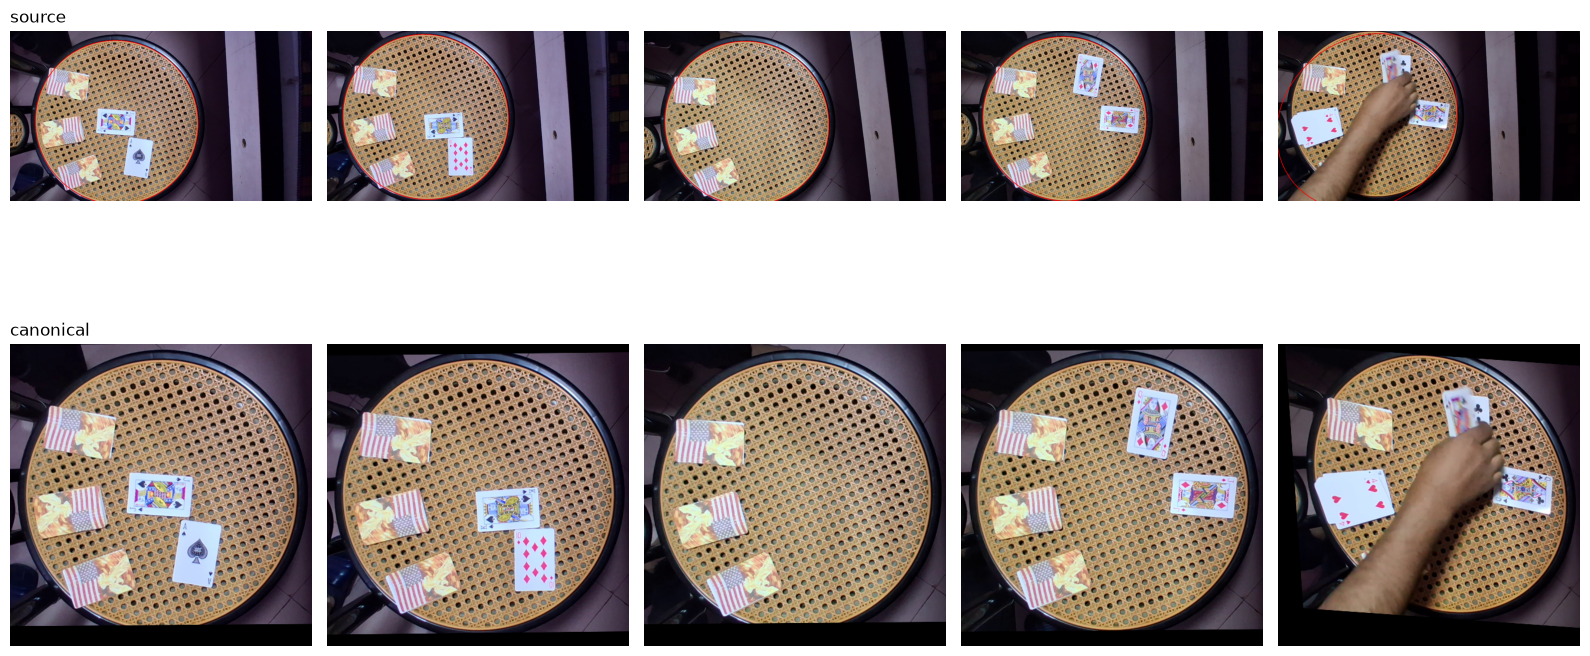

table fitted on 5/5 sampled frames


In [6]:
import cv2, numpy as np, matplotlib.pyplot as plt
from p29.vision.registration import fit_table, TableTracker, CANON_SIZE, CANON_RADIUS

cap = cv2.VideoCapture(VIDEOS[0])
n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fig, axes = plt.subplots(2, 5, figsize=(16, 9))
ok_count = 0
for col, idx in enumerate(np.linspace(n * .05, n * .95, 5).astype(int)):
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
    ok, frame = cap.read()
    if not ok:
        continue
    fit = fit_table(frame)
    shown = frame.copy()
    if fit:
        ok_count += 1
        cv2.ellipse(shown, ((fit.cx, fit.cy), (fit.major, fit.minor), fit.angle), (0, 0, 255), 2)
        warped = fit.warp(frame)
    else:
        warped = np.zeros((CANON_SIZE, CANON_SIZE, 3), np.uint8)
    axes[0, col].imshow(cv2.cvtColor(shown, cv2.COLOR_BGR2RGB)); axes[0, col].axis("off")
    axes[1, col].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)); axes[1, col].axis("off")
axes[0, 0].set_title("source", loc="left"); axes[1, 0].set_title("canonical", loc="left")
cap.release()
plt.tight_layout(); plt.show()
print(f"table fitted on {ok_count}/5 sampled frames")

## 6. Build the synthetic dataset

Real table backgrounds, procedural cards, composited in canonical space.

In [19]:
import random, shutil
from card_faces import load_gallery
from synthetic_canon import make_scene, harvest_backgrounds
from p29.vision.registration import TableTracker

GALLERY = load_gallery("data/reference")  # real scans win when present
BACKGROUNDS = harvest_backgrounds(VIDEOS, TableTracker, max_per_video=60)
print("empty-table backgrounds harvested:", len(BACKGROUNDS))
assert BACKGROUNDS, "no clean backgrounds found - check registration above"

gallery: 32 cards (0 real scans, 32 procedural)
empty-table backgrounds harvested: 120


In [10]:
import random

In [20]:
CLASS_NAMES = [f"{r}{s}" for s in ["S", "H", "D", "C"]
               for r in ["7", "8", "9", "10", "J", "Q", "K", "A"]]
CLASS_INDEX = {c: i for i, c in enumerate(CLASS_NAMES)}
assert len(CLASS_NAMES) == 32

def build_split(split, count, seed):
    rng = random.Random(seed)
    img_dir, lbl_dir = f"dataset/images/{split}", f"dataset/labels/{split}"
    shutil.rmtree(img_dir, ignore_errors=True); shutil.rmtree(lbl_dir, ignore_errors=True)
    os.makedirs(img_dir, exist_ok=True); os.makedirs(lbl_dir, exist_ok=True)
    for i in range(count):
        scene, anns = make_scene(GALLERY, BACKGROUNDS, rng)
        cv2.imwrite(f"{img_dir}/{i:06d}.jpg", scene)
        with open(f"{lbl_dir}/{i:06d}.txt", "w") as fh:
            for codeval, (x1, y1, x2, y2) in anns:
                cx = (x1 + x2) / 2 / CANON_SIZE; cy = (y1 + y2) / 2 / CANON_SIZE
                w = (x2 - x1) / CANON_SIZE;      h = (y2 - y1) / CANON_SIZE
                fh.write(f"{CLASS_INDEX[codeval]} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")
    print(f"{split}: {count} scenes")

build_split("train", N_TRAIN, seed=0)
build_split("val",   N_VAL,   seed=1)

with open("dataset/dataset.yaml", "w") as fh:
    fh.write("path: /content/dataset\ntrain: images/train\nval: images/val\n")
    fh.write(f"nc: 32\nnames: {CLASS_NAMES}\n")
print(open("dataset/dataset.yaml").read())

train: 4000 scenes
val: 600 scenes
path: /content/dataset
train: images/train
val: images/val
nc: 32
names: ['7S', '8S', '9S', '10S', 'JS', 'QS', 'KS', 'AS', '7H', '8H', '9H', '10H', 'JH', 'QH', 'KH', 'AH', '7D', '8D', '9D', '10D', 'JD', 'QD', 'KD', 'AD', '7C', '8C', '9C', '10C', 'JC', 'QC', 'KC', 'AC']



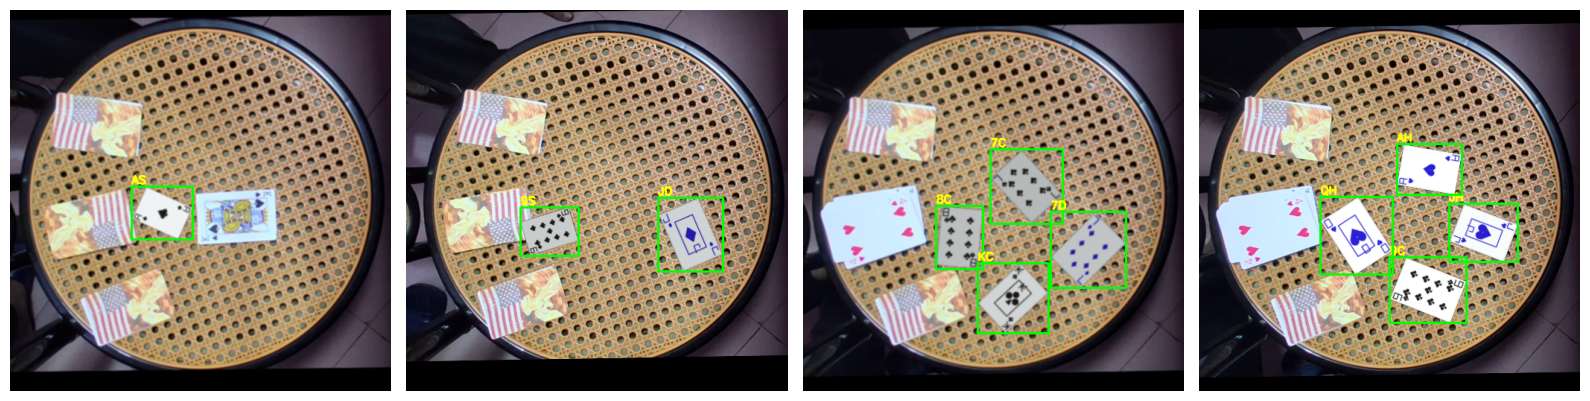

In [21]:
# Eyeball a few training samples with their boxes -- label bugs are invisible in mAP.
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
rng = random.Random(7)
for ax in axes:
    scene, anns = make_scene(GALLERY, BACKGROUNDS, rng)
    shown = scene.copy()
    for codeval, (x1, y1, x2, y2) in anns:
        cv2.rectangle(shown, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(shown, codeval, (x1, max(12, y1 - 4)), 0, 0.5, (0, 255, 255), 2)
    ax.imshow(cv2.cvtColor(shown, cv2.COLOR_BGR2RGB)); ax.axis("off")
plt.tight_layout(); plt.show()

## 7. Train

YOLO26 ships inside `ultralytics` 8.4.x. The checkpoint name has changed across
releases, so this tries the current one and falls back rather than dying on a 404 —
whatever it lands on is printed, so the result is never ambiguous.

In [7]:
from ultralytics import YOLO

MODEL = None
for candidate in ["yolo26s.pt", "yolo26n.pt", "yolo11s.pt", "yolov8s.pt"]:
    try:
        MODEL = YOLO(candidate)
        print("using:", candidate)
        break
    except Exception as exc:
        print(f"  {candidate} unavailable ({type(exc).__name__})")
assert MODEL is not None, "no usable checkpoint"

using: yolo26s.pt


In [11]:
MODEL.train(
    data="Z:\coding\PR project\dataset\dataset.yaml",
    epochs=EPOCHS,
    imgsz=IMGSZ,        # matches CANON_SIZE, so no rescaling
    batch=BATCH,
    device=0,
    workers=2,
    patience=15,
    project="runs", name="p29",
    exist_ok=True,
    # Geometry is already normalised by registration, so keep spatial aug mild
    # and let colour/lighting aug do the work.
    degrees=180.0, translate=0.08, scale=0.25, fliplr=0.0, mosaic=0.5,
    hsv_h=0.02, hsv_s=0.6, hsv_v=0.5,
)
print("best weights:", MODEL.trainer.best)

<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
C:\Users\nnahe\AppData\Local\Temp\ipykernel_25008\496089107.py:2: SyntaxWarning: invalid escape sequence '\c'
  data="Z:\coding\PR project\dataset\dataset.yaml",


New https://pypi.org/project/ultralytics/8.4.140 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.139  Python-3.12.7 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Z:\coding\PR project\dataset\dataset.yaml, degrees=180.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.02, hsv_s=0.6, hsv_v=0.5, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, m

## 8. Detector check on a real frame

Defines the one detection helper the rest of the notebook uses, and shows it working
on a real frame. Worth a look before the full run: a detector that finds nothing here
will produce an empty table in section 9 and no explanation of why.

In [ ]:
from p29.vision.regions import TableLayout, Role, assign_seats

best = YOLO(MODEL.trainer.best)
LAYOUT = TableLayout()

def detect_cards(warped, conf=CONF):
    """Detect cards in a canonical-space frame and tag each with its table role."""
    det = best.predict(warped, conf=conf, verbose=False)[0]
    items = []
    for box, cls, cf in zip(det.boxes.xyxy.cpu().numpy(),
                            det.boxes.cls.cpu().numpy().astype(int),
                            det.boxes.conf.cpu().numpy()):
        cx, cy = float((box[0] + box[2]) / 2), float((box[1] + box[3]) / 2)
        items.append({"code": CLASS_NAMES[cls], "conf": float(cf), "xy": (cx, cy),
                      "box": box, "role": LAYOUT.classify(cx, cy)})
    return items

# One real frame, overlaid.
cap = cv2.VideoCapture(VIDEOS[0])
cap.set(cv2.CAP_PROP_POS_FRAMES, int(200 * cap.get(cv2.CAP_PROP_FPS)))
ok, frame = cap.read(); cap.release()
fit = fit_table(frame) if ok else None

if fit is None:
    print("registration failed on this frame")
else:
    warped = fit.warp(frame)
    items = detect_cards(warped)
    trick = [i for i in items if i["role"] is Role.TRICK]
    if trick:
        for item, seat in zip(trick, assign_seats(np.array([i["xy"] for i in trick]))):
            item["seat"] = seat

    shown = warped.copy()
    for i in items:
        x1, y1, x2, y2 = i["box"].astype(int)
        cv2.rectangle(shown, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(shown, f"{i['code']} {i.get('seat', i['role'].value)}",
                    (x1, max(12, y1 - 5)), 0, 0.45, (0, 255, 255), 1)
    plt.figure(figsize=(7, 7)); plt.imshow(cv2.cvtColor(shown, cv2.COLOR_BGR2RGB))
    plt.axis("off"); plt.show()
    print(f"{len(items)} card(s) detected, {len(trick)} in the trick area")

## 9. Full pipeline — every game, every trick, every player

**This is the deliverable.** Both videos are processed end to end and the result is,
per game and per trick, which card each player played.

Three things happen here that single-frame analysis cannot do:

* **Trick segmentation** — cards pile up in the play area and are swept away when the
  trick is taken. That sweep is the boundary between tricks.
* **Voting** — a card sits on the table for many frames and so is classified many
  times. The consensus is much stronger than any single frame, which matters a lot at
  ~55x85 px per card.
* **Uniqueness** — each of the 32 cards is played exactly once per game, so the whole
  game is solved as one assignment problem instead of 32 independent guesses. If two
  slots both want `9H`, only the stronger keeps it and the other is pushed to its best
  remaining option. This is the main error-corrector.

In [ ]:
from tracking import (
    Detection, TrickSegmenter, split_games, enforce_uniqueness,
    to_player_mapping, SEAT_TO_PLAYER,
)

def process_video(video_path, sample_fps=SAMPLE_FPS, conf=CONF, verbose=True):
    """Run detection + segmentation over a whole video. Returns raw tricks."""
    cap = cv2.VideoCapture(video_path)
    fps = max(cap.get(cv2.CAP_PROP_FPS), 1.0)
    step = max(1, int(round(fps / sample_fps)))

    tracker = TableTracker()
    # These two guards are what stop detector flicker from shredding one trick into
    # many. Measured on the real footage with a classical blob detector, a naive
    # emptiness test fired ~89 times on a video containing 8 tricks -- so a trick
    # must also survive a minimum duration. Tune both with the section 9 checks.
    segmenter = TrickSegmenter(
        min_empty_frames=int(sample_fps * 1.5),
        min_peak_cards=2,
        min_trick_frames=int(fps * 2.0),
    )
    seen = fitted = 0

    # Decode sequentially and skip with grab(); seeking to each sampled frame
    # measured ~20x slower on this footage, and lands on keyframes rather than the
    # frame asked for.
    idx = -1
    while True:
        if not cap.grab():
            break
        idx += 1
        if idx % step:
            continue
        ok, frame = cap.retrieve()
        if not ok:
            break
        seen += 1
        fit = tracker.update(frame)
        if fit is None:
            continue
        fitted += 1

        found = [
            Detection(i["code"], i["conf"], *i["xy"])
            for i in detect_cards(fit.warp(frame), conf=conf)
            if i["role"] is Role.TRICK
        ]
        segmenter.feed(idx, found)

    cap.release()
    tricks = segmenter.finish()
    if verbose:
        print(f"{os.path.basename(video_path)}: {seen} frames sampled, "
              f"{fitted} registered, {len(tricks)} tricks segmented")
    return tricks, fps

In [ ]:
def reconstruct(video_path):
    """Full reconstruction for one video -> list of games, each a list of tricks."""
    tricks, fps = process_video(video_path)
    # A deal takes far longer than the gap between tricks in a game.
    games = split_games(tricks, tricks_per_game=8, deal_gap_frames=int(fps * 25))

    out = []
    for g_idx, game_tricks in enumerate(games):
        resolved = enforce_uniqueness(game_tricks, CLASS_NAMES)
        rows = []
        for t_idx, (raw, seat_map) in enumerate(zip(game_tricks, resolved)):
            rows.append({
                "trick": t_idx,
                "start_s": round(raw.start_frame / fps, 1),
                "cards_seen": raw.peak_cards,
                "players": to_player_mapping(seat_map),
            })
        out.append({"game": g_idx, "tricks": rows})
    return out

ALL_GAMES = {}
for path in VIDEOS:
    ALL_GAMES[os.path.basename(path)] = reconstruct(path)
print("\ndone")

### The answer — cards played, per game and per trick

In [ ]:
import json
import pandas as pd

records, PLAY_ARRAY = [], {}
for video, games in ALL_GAMES.items():
    PLAY_ARRAY[video] = []
    for game in games:
        PLAY_ARRAY[video].append(
            [[t["players"].get(p) for p in (1, 2, 3, 4)] for t in game["tricks"]])
        for trick in game["tricks"]:
            row = {"video": video, "game": game["game"], "trick": trick["trick"],
                   "t(s)": trick["start_s"], "seen": trick["cards_seen"]}
            for player in (1, 2, 3, 4):
                row[f"P{player}"] = trick["players"].get(player, "-")
            records.append(row)

TABLE = pd.DataFrame(records)
pd.set_option("display.width", 140)
print(TABLE.to_string(index=False) if len(TABLE) else "no tricks reconstructed")

print("\n[game][trick] -> [P1, P2, P3, P4]")
print(json.dumps(PLAY_ARRAY, indent=1))

with open("reconstruction.json", "w") as fh:
    json.dump(PLAY_ARRAY, fh, indent=1)
TABLE.to_csv("reconstruction.csv", index=False)
print("\nsaved reconstruction.json / reconstruction.csv")

### Read the diagnostics before trusting the table

`seen` is how many cards were visible at the trick's fullest. **A trick showing fewer
than 4 was never fully observed**, so its missing seats are gaps, not errors — usually a
hand covering the table at the wrong moment.

Two sanity checks worth doing on the output above:

* **8 tricks per game.** More means one trick got split by a dropout; fewer means two
  merged, or the sweep was missed. Adjust `min_empty_frames` in `process_video`.
* **3 games total** across the two videos (1 + 2). If `split_games` disagrees, tune
  `deal_gap_frames` — it is what separates a deal from an ordinary between-trick pause.

In [ ]:
for video, games in ALL_GAMES.items():
    print(f"\n{video}: {len(games)} game(s)")
    for game in games:
        n_tricks = len(game["tricks"])
        full = sum(1 for t in game["tricks"] if t["cards_seen"] == 4)
        named = sum(len(t["players"]) for t in game["tricks"])
        flag = "" if n_tricks == 8 else "   <-- expected 8"
        print(f"  game {game['game']}: {n_tricks} tricks{flag}, "
              f"{full} fully observed, {named}/32 card slots filled")

## 10. Rules engine — trick to score

This part is fully tested and independent of the CV.

In [ ]:
from cards import Card, Suit
from scoring import TrumpInfo, score_hand_from_plays

def score_reconstructed_game(game, trump_suit, first_leader=1, bid_team=None, bid=None):
    """Score a game from section 9, deriving play order from the trick outcomes."""
    plays = []
    for trick in game["tricks"]:
        players = trick["players"]
        if len(players) != 4:
            print(f"  trick {trick['trick']}: incomplete ({sorted(players)}) - skipped")
            continue
        plays.append({p: Card.from_code(c) for p, c in players.items()})
    if not plays:
        return None
    return score_hand_from_plays(
        plays, TrumpInfo(suit=trump_suit, reveal_trick_index=0),
        first_leader=first_leader, bidding_team=bid_team, bid=bid)


# Trump is not read off the table yet (section 11), so supply it per game.
TRUMP_BY_GAME = {}    # e.g. {("29-gameplay-1.mp4", 0): Suit.DIAMONDS}
DEFAULT_TRUMP = Suit(DEFAULT_TRUMP_CODE)

for video, games in ALL_GAMES.items():
    for game in games:
        key = (video, game["game"])
        print(f"\n{video} game {game['game']}:")
        result = score_reconstructed_game(
            game, TRUMP_BY_GAME.get(key, DEFAULT_TRUMP),
            first_leader=FIRST_LEADER, bid_team=BID_TEAM, bid=BID)
        if result is None:
            print("  no complete tricks to score")
            continue
        print("  leaders     :", result.trick_leaders, "(derived)")
        print("  winners     :", result.trick_winners)
        print("  team points :", result.team_points)
        print("  marriage    :", result.marriage_player)
        print("  contract    :", result.contract_made, "->", result.winning_team)

Play order is **derived, not observed**: the winner of a trick leads the next one,
going round the table from there. So the whole sequence follows from one input —
who led the first trick (the bid winner in *29*) — set as `FIRST_LEADER` above.

This is not bookkeeping. The leader fixes the **led suit**, which decides the winner
whenever no trump is played. A wrong leader can flip a winner, which changes the next
leader, so an early mistake propagates through the rest of the hand. If the scores
look wrong, check `FIRST_LEADER` before suspecting the detector.

## 11. Where this stands

**Structurally complete.** Video in, per-game/per-trick/per-player cards out.

- Table registration removes the hand-held drift (verified on both videos).
- Canonical region model separates trick / trump / counter / hand by position.
- Seat assignment by bearing from the trick centroid, robust to table wander.
- Trick segmentation, per-trick voting, game splitting, and the once-per-game
  uniqueness constraint as a global assignment.
- Rules, marriage detection and bid resolution — fully unit-tested.

**The one thing standing between this and correct answers: the card scans.**
The deck is currently rendered procedurally, so the model has never seen your actual
cards. *Where* cards are and *when* tricks happen should transfer to real footage;
*which card* it is will largely not. Everything else is in place, so the fix is a
one-step data swap: put the 32 scans in `data/reference/<CODE>.png` (`JS.png`,
`10H.png`, …) and re-run from section 6. No code changes.

Until then, treat section 9's table as a **pipeline demonstration**, not a reading of
your games. The structure — 3 games, 8 tricks each, 4 players — is the part to check
now; the card names are the part to distrust.

**Also still open**
- **Trump and counter spots** are unset, so those cards fall through to `HAND`/`TRICK`.
  Set `TableLayout(trump_spot=Disc(...), counter_spot=Disc(...))` once their positions
  are pinned down. Trump suit therefore is not yet read automatically — section 10
  takes it as input.
- **Who led the first trick** — the one ordering fact the video cannot give you. In *29*
  it is the bid winner, so it comes in with the bid; set `FIRST_LEADER` in section 10.
  Every later leader is derived (winner of a trick leads the next).

**On the 0-misclassification target:** a played card is roughly 55×85 px in the source
video and the rank index about 10 px. Registration upscales it but cannot add detail
that was never recorded. Real scans, temporal voting and the uniqueness constraint are
all necessary here, not optional — and a second recording at higher resolution would
do more for the target than any modelling change.